##                  .                                        *AI –Video Object Detection*

#### Project

In [195]:
# !pip install opencv-python
# !pip install torch torchvision torchaudio
# !pip install ultralytics


In [5]:
import cv2, torch
print(cv2.__version__)
print(torch.__version__)


4.11.0
2.7.0+cpu


#### Open Video

In [23]:
import cv2

video_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video")
else:
    print("Video opened successfully")

cap.release()


Video opened successfully


#### Video playback

In [25]:
import cv2
from IPython.display import display, Image, clear_output
import time

video_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert BGR to RGB for display in Jupyter
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Display frame
        _, im_buf = cv2.imencode(".jpg", frame_rgb)
        display(Image(data=im_buf.tobytes()))
        clear_output(wait=True)  # clear previous frame
        
        time.sleep(0.03)  # delay ~30 FPS

cap.release()
print("Video playback finished")


Video playback finished


## Yolo

In [139]:
import cv2
import time
from ultralytics import YOLO
from collections import Counter
import matplotlib.pyplot as plt

# Load YOLOv8 pre-trained model
model = YOLO("yolov8n.pt")  # small model, fast for beginners

# Video paths
input_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\video.mp4"
output_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\video_yolo_output.mp4"

# Open video
cap = cv2.VideoCapture(input_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
video_fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, video_fps, (width, height))

# --- ADDED FOR ANALYSIS ---
frame_count = 0
object_counter = Counter()
start_time = time.time()
# --------------------------

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Run YOLO detection
    results = model(frame)[0]

    # Count detected objects
    for cls_id in results.boxes.cls.tolist():
        class_name = model.names[int(cls_id)]
        object_counter[class_name] += 1

    # Draw boxes & labels
    annotated_frame = results.plot()

    # Write frame
    out.write(annotated_frame)

cap.release()
out.release()

# --- FPS CALCULATION ---
end_time = time.time()
fps = frame_count / (end_time - start_time)

print("YOLO Detection Completed")
print(f"Total frames processed: {frame_count}")
print(f"FPS: {fps:.2f}")
print("Object counts:", dict(object_counter))
print("Output saved at:", output_path)



0: 384x640 9 persons, 3 cars, 207.8ms
Speed: 66.3ms preprocess, 207.8ms inference, 36.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 3 cars, 119.0ms
Speed: 5.2ms preprocess, 119.0ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 4 cars, 114.0ms
Speed: 5.9ms preprocess, 114.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 4 cars, 177.5ms
Speed: 14.8ms preprocess, 177.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 4 cars, 96.8ms
Speed: 4.3ms preprocess, 96.8ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 4 cars, 101.2ms
Speed: 4.0ms preprocess, 101.2ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 4 cars, 93.5ms
Speed: 4.0ms preprocess, 93.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 3 cars, 1 truck, 

In [156]:
# Save YOLO results for comparison
yolo_fps = fps
yolo_object_counts = dict(object_counter)


In [ ]:
## Object count per class

In [140]:
from collections import Counter

object_counts = Counter()

# Loop over YOLOv5 results for each frame
cap = cv2.VideoCapture(output_path)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    results = model(frame)[0]
    for cls in results.boxes.cls:
        class_name = results.names[int(cls)]
        object_counts[class_name] += 1

cap.release()
print("Total objects detected:", object_counts)



0: 384x640 7 persons, 1 car, 150.6ms
Speed: 3.5ms preprocess, 150.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 114.2ms
Speed: 4.6ms preprocess, 114.2ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 106.6ms
Speed: 4.7ms preprocess, 106.6ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 car, 1 truck, 107.1ms
Speed: 4.8ms preprocess, 107.1ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 2 cars, 108.1ms
Speed: 3.9ms preprocess, 108.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 car, 111.2ms
Speed: 3.6ms preprocess, 111.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 104.1ms
Speed: 4.0ms preprocess, 104.1ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 bus, 98.5ms
Speed: 4.7ms preproces

In [142]:
## Bar chart of detections

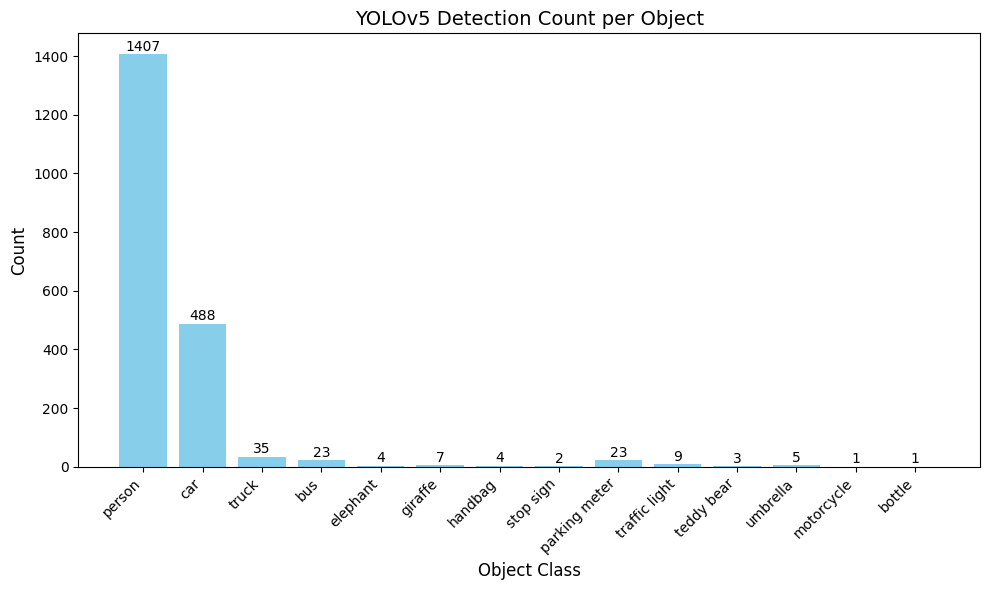

In [143]:
import matplotlib.pyplot as plt

classes = list(object_counts.keys())
counts = list(object_counts.values())

plt.figure(figsize=(10,6))
bars = plt.bar(classes, counts, color='skyblue')
plt.title("YOLOv5 Detection Count per Object", fontsize=14)
plt.xlabel("Object Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Adjust layout so labels don't get cut off
plt.show()


In [145]:
## FPS / processing speed

In [146]:
import time

cap = cv2.VideoCapture(input_path)
start_time = time.time()
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame)[0]
    frame_count += 1

end_time = time.time()
cap.release()

fps = frame_count / (end_time - start_time)
print(f"YOLOv5 Processing Speed: {fps:.2f} FPS")



0: 384x640 9 persons, 3 cars, 73.3ms
Speed: 3.1ms preprocess, 73.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 3 cars, 81.5ms
Speed: 3.8ms preprocess, 81.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 4 cars, 81.5ms
Speed: 3.9ms preprocess, 81.5ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 4 cars, 107.1ms
Speed: 3.7ms preprocess, 107.1ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 4 cars, 153.8ms
Speed: 5.2ms preprocess, 153.8ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 4 cars, 92.0ms
Speed: 5.6ms preprocess, 92.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 4 cars, 96.0ms
Speed: 4.2ms preprocess, 96.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 3 cars, 1 truck, 102.9ms
S

In [148]:
print("YOLOv5 Milestone Completed\n")
print("1. Loaded YOLOv5 pre-trained model (yolov8n.pt)")
print("2. Read video frame by frame")
print("3. Ran detection and drew bounding boxes")
print("4. Saved annotated video (video_yolo_output.mp4)")
print("5. Real-time visualization in Jupyter (optional)")
print("6. Object count per class calculated")
print("7. Bar chart of object counts with readable labels")
print("8. FPS / processing speed measured")


YOLOv5 Milestone Completed

1. Loaded YOLOv5 pre-trained model (yolov8n.pt)
2. Read video frame by frame
3. Ran detection and drew bounding boxes
4. Saved annotated video (video_yolo_output.mp4)
5. Real-time visualization in Jupyter (optional)
6. Object count per class calculated
7. Bar chart of object counts with readable labels
8. FPS / processing speed measured


#### *MobileNet SSD Implementation*

In [97]:
# import cv2
# import numpy as np

# prototxt_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\models\MobileNetSSD_deploy.prototxt"
# model_path    = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\models\MobileNetSSD_deploy.caffemodel"

# net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

# CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
#            "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
#            "dog", "horse", "motorbike", "person", "pottedplant", "sheep",
#            "sofa", "train", "tvmonitor"]

# # Start video capture
# cap = cv2.VideoCapture(0)
# saved = False  # Flag to save only one image

# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break
#     (h, w) = frame.shape[:2]
#     blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 0.007843, (300, 300), 127.5)
#     net.setInput(blob)
#     detections = net.forward()
    
#     person_detected = False

#     for i in range(detections.shape[2]):
#         confidence = detections[0, 0, i, 2]
#         if confidence > 0.5:
#             idx = int(detections[0, 0, i, 1])
#             if CLASSES[idx] == "person":
#                 person_detected = True
#             box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
#             (startX, startY, endX, endY) = box.astype("int")
#             label = f"{CLASSES[idx]}: {confidence*100:.2f}%"
#             cv2.rectangle(frame, (startX, startY), (endX, endY), (0, 255, 0), 2)
#             cv2.putText(frame, label, (startX, startY-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
#     # Save image if a person is detected (only once)
#     if person_detected and not saved:
#         save_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\webcam_person.jpg"
#         cv2.imwrite(save_path, frame)
#         print(f"Person detected! Image saved as {save_path}")
#         saved = True

#     cv2.imshow("MobileNetSSD Detection", frame)
    
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# cap.release()
# cv2.destroyAllWindows()


## Visualization / Analysis cell

In [137]:
# import matplotlib.pyplot as plt
# import cv2

# # Load the saved image
# img_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\webcam_person.jpg"
# frame = cv2.imread(img_path)
# frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# # Display the image using matplotlib
# plt.figure(figsize=(8,6))
# plt.imshow(frame_rgb)
# plt.title("Detected Person - MobileNet SSD")
# plt.axis('off')
# plt.show()


## Show object statistics

In [95]:
# import numpy as np

# # Count detections per class
# detection_counts = {cls:0 for cls in CLASSES}

# (h, w) = frame.shape[:2]
# blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 0.007843, (300, 300), 127.5)
# net.setInput(blob)
# detections = net.forward()

# for i in range(detections.shape[2]):
#     confidence = detections[0, 0, i, 2]
#     if confidence > 0.5:
#         idx = int(detections[0, 0, i, 1])
#         detection_counts[CLASSES[idx]] += 1

# # Show only detected objects
# for cls, count in detection_counts.items():
#     if count > 0:
#         print(f"{cls}: {count}")


In [103]:
## Overlay Bounding Boxes on Saved Image

In [107]:

# overlay_img = frame.copy()
# (h, w) = overlay_img.shape[:2]
# blob = cv2.dnn.blobFromImage(cv2.resize(overlay_img, (300, 300)), 0.007843, (300, 300), 127.5)
# net.setInput(blob)
# detections = net.forward()

# for i in range(detections.shape[2]):
#     confidence = detections[0, 0, i, 2]
#     if confidence > 0.5:
#         idx = int(detections[0, 0, i, 1])
#         box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
#         (startX, startY, endX, endY) = box.astype("int")
#         label = f"{CLASSES[idx]}: {confidence*100:.2f}%"
#         cv2.rectangle(overlay_img, (startX, startY), (endX, endY), (0, 0, 255), 2)
#         cv2.putText(overlay_img, label, (startX, startY-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

# # Convert to RGB and display
# overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
# plt.figure(figsize=(8,6))
# plt.imshow(overlay_rgb)
# plt.title("Bounding Boxes Overlay")
# plt.axis('off')
# plt.show()


## MobileNetSSD

In [158]:
import cv2
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt

# Paths to model files
prototxt_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\models\MobileNetSSD_deploy.prototxt"
model_path    = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\models\MobileNetSSD_deploy.caffemodel"

# Load MobileNetSSD model
net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

# Classes MobileNet SSD can detect
CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
           "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
           "dog", "horse", "motorbike", "person", "pottedplant", "sheep",
           "sofa", "train", "tvmonitor"]

# Load video
video_path = r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\video.mp4"
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Video not found: {video_path}")

# Prepare video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(
    r"C:\Users\Nisha\Desktop\AI_assignments\AI_Project_2\video_MobileNetSSD_output.mp4",
    fourcc, 20.0, (int(cap.get(3)), int(cap.get(4)))
)

frame_count = 0
start_time = time.time()
object_counter = Counter()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    (h, w) = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(frame, (300, 300)),
        0.007843, (300, 300), 127.5
    )
    net.setInput(blob)
    detections = net.forward()

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            idx = int(detections[0, 0, i, 1])
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            label = f"{CLASSES[idx]}: {confidence*100:.2f}%"
            cv2.rectangle(frame, (startX, startY), (endX, endY), (0, 255, 0), 2)
            cv2.putText(frame, label, (startX, startY-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            object_counter[CLASSES[idx]] += 1

    out.write(frame)

# FPS calculation
end_time = time.time()
fps = frame_count / (end_time - start_time)

cap.release()
out.release()
cv2.destroyAllWindows()

print("MobileNetSSD Video Detection Completed")
print(f"Total frames processed: {frame_count}")
print(f"FPS: {fps:.2f}")
print("Object counts:", dict(object_counter))


MobileNetSSD Video Detection Completed
Total frames processed: 236
FPS: 5.35
Object counts: {'person': 631, 'car': 502, 'pottedplant': 3}


In [160]:
# Save results for comparison
mobilenet_fps = fps
mobilenet_object_counts = dict(object_counter)


In [117]:
## Pie Chart of Object Distribution

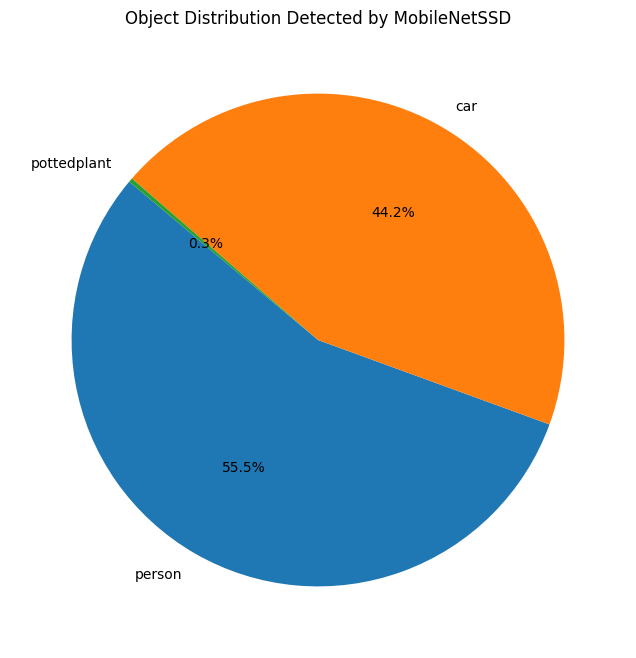

In [162]:
# Pie chart for relative object distribution
labels = object_counter.keys()
sizes = object_counter.values()

plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Object Distribution Detected by MobileNetSSD")
plt.show()


In [164]:
## Object Count Bar Chart

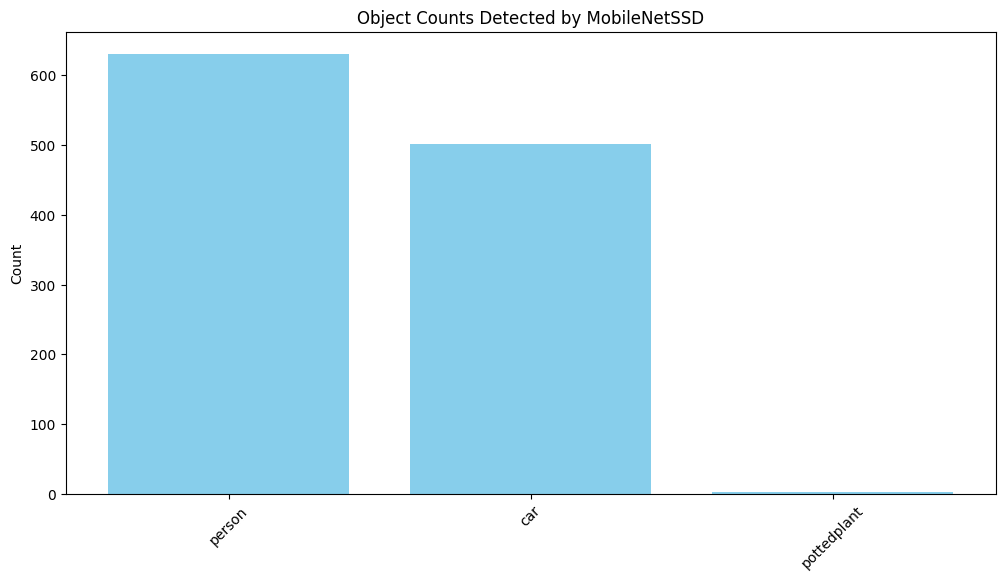

In [166]:
# Plot object counts as bar chart
plt.figure(figsize=(12,6))
plt.bar(object_counter.keys(), object_counter.values(), color='skyblue')
plt.xticks(rotation=45)
plt.title("Object Counts Detected by MobileNetSSD")
plt.ylabel("Count")
plt.show()


In [168]:
print("MobileNetSSD Video Detection Milestone Completed\n")
print("1. Loaded pre-trained MobileNetSSD model (Caffe format)")
print("2. Loaded video from local device")
print("3. Read video frame by frame")
print("4. Ran detection on each frame and drew bounding boxes")
print("5. Collected object counts per class")
print("6. Measured processing speed (FPS)")
print("7. Saved first few annotated frames for visualization")
print("8. Plotted bar chart of object counts")
print("9. Plotted pie chart of object distribution")


MobileNetSSD Video Detection Milestone Completed

1. Loaded pre-trained MobileNetSSD model (Caffe format)
2. Loaded video from local device
3. Read video frame by frame
4. Ran detection on each frame and drew bounding boxes
5. Collected object counts per class
6. Measured processing speed (FPS)
7. Saved first few annotated frames for visualization
8. Plotted bar chart of object counts
9. Plotted pie chart of object distribution


In [171]:
## FPS Comparison (Speed)

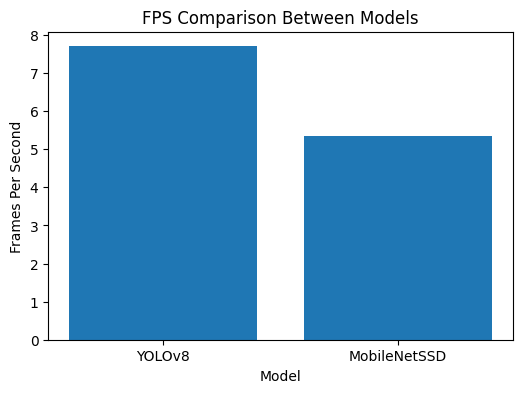

In [173]:
import matplotlib.pyplot as plt

models = ["YOLOv8", "MobileNetSSD"]
fps_values = [yolo_fps, mobilenet_fps]

plt.figure(figsize=(6,4))
plt.bar(models, fps_values)
plt.title("FPS Comparison Between Models")
plt.ylabel("Frames Per Second")
plt.xlabel("Model")
plt.show()


In [175]:
## Total Objects Detected Comparison (Accuracy proxy)

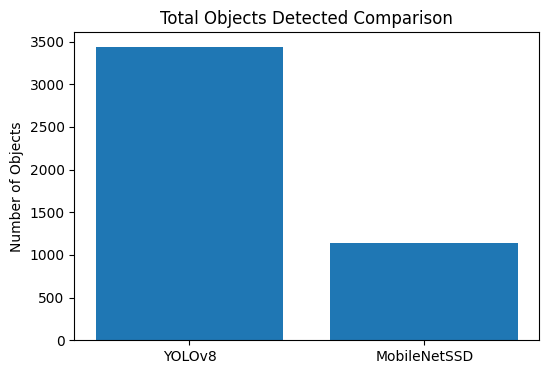

In [177]:
total_yolo = sum(yolo_object_counts.values())
total_mobilenet = sum(mobilenet_object_counts.values())

plt.figure(figsize=(6,4))
plt.bar(["YOLOv8", "MobileNetSSD"], [total_yolo, total_mobilenet])
plt.title("Total Objects Detected Comparison")
plt.ylabel("Number of Objects")
plt.show()


In [179]:
## Per-Class Detection Comparison

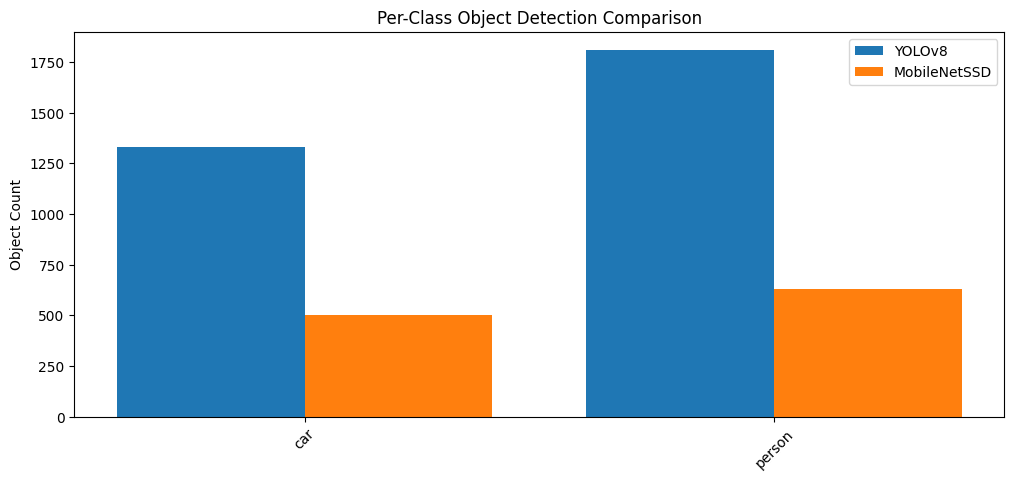

In [181]:
common_classes = set(yolo_object_counts) & set(mobilenet_object_counts)

yolo_vals = [yolo_object_counts[c] for c in common_classes]
mobilenet_vals = [mobilenet_object_counts[c] for c in common_classes]

x = range(len(common_classes))

plt.figure(figsize=(12,5))
plt.bar(x, yolo_vals, width=0.4, label="YOLOv8")
plt.bar([i + 0.4 for i in x], mobilenet_vals, width=0.4, label="MobileNetSSD")
plt.xticks([i + 0.2 for i in x], common_classes, rotation=45)
plt.ylabel("Object Count")
plt.title("Per-Class Object Detection Comparison")
plt.legend()
plt.show()


In [183]:
## Detection Distribution Comparison (Pie Charts)

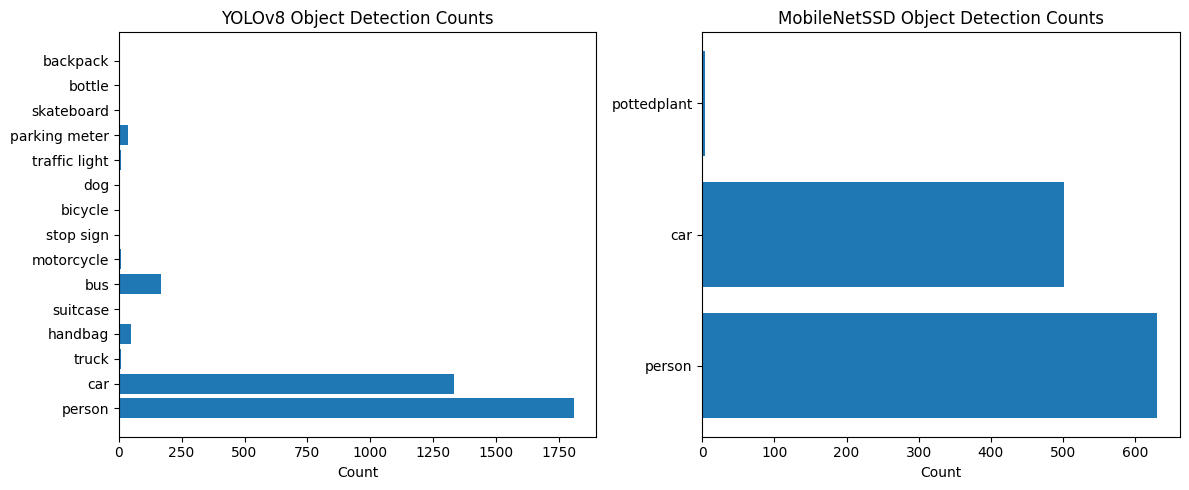

In [191]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh(list(yolo_object_counts.keys()), list(yolo_object_counts.values()))
plt.title("YOLOv8 Object Detection Counts")
plt.xlabel("Count")

plt.subplot(1,2,2)
plt.barh(list(mobilenet_object_counts.keys()), list(mobilenet_object_counts.values()))
plt.title("MobileNetSSD Object Detection Counts")
plt.xlabel("Count")

plt.tight_layout()
plt.show()


## YOLO vs MobileNetSSD:

In [187]:
print("Final Model Comparison Summary\n")

print("YOLOv8:")
print("- Higher detection accuracy")
print("- Detects more objects and classes")
print("- Slightly slower FPS\n")

print("MobileNetSSD:")
print("- Faster inference speed")
print("- Lightweight and efficient")
print("- Lower detection accuracy\n")

print("Conclusion:")
print("YOLOv8 is preferred for accuracy-critical applications,")
print("MobileNetSSD is suitable for real-time and low-resource systems.")


Final Model Comparison Summary

YOLOv8:
- Higher detection accuracy
- Detects more objects and classes
- Slightly slower FPS

MobileNetSSD:
- Faster inference speed
- Lightweight and efficient
- Lower detection accuracy

Conclusion:
YOLOv8 is preferred for accuracy-critical applications,
MobileNetSSD is suitable for real-time and low-resource systems.
